# Practical L10

<div class="page-subtitle">
The Alpine Snow Decline
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/09_practical_L10.ipynb)

---

```{admonition} Environment Setup Required
:class: warning

Before proceeding with this practical, please ensure that several specialized packages are installed in your course environment. You can install them all at once by running the following command in your terminal or directly in a notebook cell:

`%pip install cmcrameri gdown pooch hvplot jupyter_bokeh rioxarray geoviews -q`
```

```{admonition} A Note on Time-Series Data Cubes
:class: important

In the previous practical, you compared two distinct snapshots in time. Now, we are adding the dimension of time in its entirety. You will be working with a 25-year time-series data cube. Instead of just identifying *where* things changed, you will use `xarray` to quantify the *rate* of change over decades, both at individual point locations and across massive multi-dimensional arrays using pixel-wise linear regressions.
```

## Learning objectives

After completing this practical, you will be able to:

  * ingest and clip multi-dimensional data cubes using `rioxarray` and GeoPandas.
  * extract 1D time-series data from 3D arrays using specific real-world coordinates.
  * calculate pixel-wise temporal trends across entire spatial matrices using `.polyfit()`.
  * sample raster data at vector point locations (centroids) to correlate environmental variables (elevation vs. snow decline).

---

## Practical storyline

You are a climatologist working for MeteoSwiss, tasked with investigating long-term snow cover reduction in the European Alps. The Swiss Ski Resorts Council is highly concerned about the viability of their infrastructure and is wondering how their winter seasons are expected to change over the next decades. 

You have been provided with a 25-year multi-dimensional data cube of [Snow Cover Frequency](https://code.earthengine.google.com/6d4fc5945cd77fafdc014f1b62e57ca6) (SCF), which is representing the ratio of "snow days" to the full year for the European Alps. You also have access to a [Digital Elevation Model](https://code.earthengine.google.com/adea13309b1639bbc67d3c4f5e63bb22) (DEM) and a mask of [large water bodies](https://code.earthengine.google.com/b10ac8e02c8a0ba7667b009f21ab31e9) the area, a [perimeter boundary of the European Alps](https://www.atlas.alpconv.org/catalogue/#/?q=alpine%20convention&d=432%3Bdataset%3Bvector), and a database of current ski resort infrastructure ([`bahnen-winter_2056.gpkg`](https://data.geo.admin.ch/browser/index.html#/collections/ch.swisstopo.bahnen-winter/items/bahnen-winter?.language=en)).

Your task is to clip the climate data to the region of interest, extract historical trends for large resorts, calculate a region-wide map of snow decline, and finally, evaluate how the physical elevation of chairlifts correlates with the severity of snow loss.

---

## Part 0 – The Data Intake Helper

Run the cell below to download the required datasets (the 25-year SCF data cube, the DEM, the Alpine perimeter, and the ski lift infrastructure) to your local environment.

### Tasks

1.  Execute the setup code to create your local working directory and fetch the files.

In [1]:
import os
import geopandas as gpd
import xarray as xr
import rioxarray
import numpy as np
import matplotlib.pyplot as plt
import gdown
from scipy.stats import linregress
import cmcrameri.cm as cmc
from matplotlib.colors import LightSource

# Create data directory
data_folder = "data"
# os.makedirs(data_folder, exist_ok=True)

# Dictionary of file IDs and their output names
datasets = {
    "scf_alps_25yr.tif": "1Uds7kAGnbl7gdFQrDRIdeRXMSpztiO3i",
    "dem_alps.tif": "1Q895LhVvtbEoeg1LL9wQFGdmg11M9x_N",
    "lakes_alps.tif": "1VPuhMBWuX_JX3Ud798vd9gccPUAwqmIz",
    "alpine_perimeter.zip": "1945H8BAefR6C8umzaLKPhrVfGT_uFRNN",
    "bahnen-winter_2056.gpkg": "1c2f4Nwe5f4Pp5leDSuQZj1nyRoluJoOT",
}

"""
for filename, file_id in datasets.items():
    filepath = os.path.join(data_folder, filename)
    if not os.path.exists(filepath):
        print(f"Downloading {filename}...")
        url = f"https://drive.google.com/uc?id={file_id}"
        gdown.download(url, filepath, quiet=False)
    else:
        print(f"{filename} already exists.")
"""

scf_fp = os.path.join(data_folder, "scf_alps_25yr.tif")
dem_fp = os.path.join(data_folder, "dem_alps.tif")
lakes_fp = os.path.join(data_folder, "lakes_alps.tif")
perim_fp = os.path.join(data_folder, "alpine_perimeter.zip")
lifts_fp = os.path.join(data_folder, "bahnen-winter_2056.gpkg")

---

## Part 1 – Data Intake & Visualization

Data cubes can be memory-intensive. Before we perform any time-series analysis, we should spatially subset our data to just the European Alps perimeter.

Because `.tif` files naturally load their layers as a `band` dimension, we will also quickly rename that dimension to `time` and assign it actual years (e.g., 2001 to 2025) to make our downstream plotting and trend analysis mathematically coherent.

### Tasks
1. **Load Vector Data:** Load the `alpine_perimeter.gpkg` using GeoPandas. Load the `bahnen-winter_2056.gpkg`, filter it so `type == "chairlift"`, and extract the centroids of these geometries into a new GeoDataFrame called `chairlifts_pts`. Reproject the `chairlifts_pts` from `epsg:2056` to `epsg:3035`.
2. **Load and Clip Rasters:** Use `rioxarray.open_rasterio()` to open the SCF data cube, DEM, and the Lake Mask. Clip them all to the bounding box of the alpine perimeter ([`total_bounds`](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoSeries.total_bounds.html)) to save memory using [`rio.clip.box`](https://corteva.github.io/rioxarray/html/examples/clip_box.html#Clip-using-a-bounding-box).
3. **Format the Cube:** For the clipped SCF data cube, [rename](https://docs.xarray.dev/en/latest/generated/xarray.DataArray.rename.html) the `band` dimension to `time`. Assign an array of years (e.g., `np.arange(2001, 2026)`) to this new `time` coordinate.
4. **Visualize the Data:** Calculate the [mean](https://docs.xarray.dev/en/latest/generated/xarray.Dataset.mean.html#xarray.Dataset.mean) Snow Cover Fraction across time. Use `LightSource` to generate a hillshade from the DEM, and blend the mean SCF over the topography. Overlay the lake mask, the chairlifts, and the perimeter boundary.

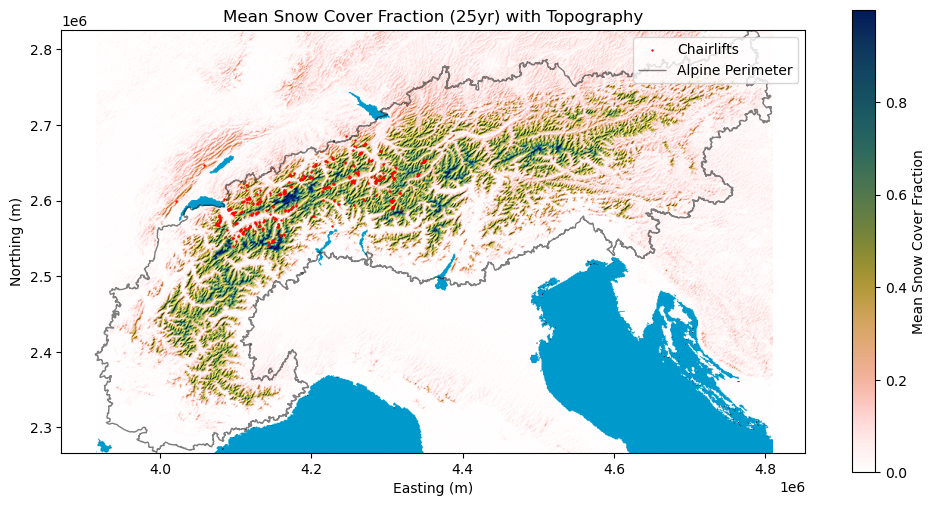

In [7]:
# Write your code here

perimeter = gpd.read_file(perim_fp)

lifts = gpd.read_file(lifts_fp)
chairlifts = lifts[lifts["type"] == "chairlift"].copy()
chairlifts['geometry'] = chairlifts.geometry.centroid
chairlifts_pts = chairlifts.to_crs("EPSG:3035")

bounds = perimeter.total_bounds

clipped_scf = rioxarray.open_rasterio(scf_fp).rio.clip_box(*bounds)
clipped_dem = rioxarray.open_rasterio(dem_fp).rio.clip_box(*bounds)
clipped_lake = rioxarray.open_rasterio(lakes_fp).rio.clip_box(*bounds)

scf_cube = clipped_scf.rename({'band': 'time'})
scf_cube = scf_cube.assign_coords(time=np.arange(2001, 2026))

ls = LightSource(azdeg=315, altdeg=45)
scf_mean = scf_cube.mean(dim='time').squeeze().values
dem_data = clipped_dem.values[0]
hillshade = ls.hillshade(dem_data, vert_exag=1)
extent = [clipped_dem.x.min(), clipped_dem.x.max(), clipped_dem.y.min(), clipped_dem.y.max()]

# Colormap
cmap = cmc.batlowW_r
norm = plt.Normalize(vmin=np.nanmin(scf_mean), vmax=np.nanmax(scf_mean))

# Map SCF to RGB
scf_rgb = cmap(norm(scf_mean))[:, :, :3]

# Shade the RGB
blended_rgb = ls.shade_rgb(scf_rgb, elevation=hillshade, blend_mode='overlay', vert_exag=2)

# Add Lakes
lakes_mask = clipped_lake.values[0] > 0
lake_color = np.array([0.0, 0.6, 0.8])
blended_rgb[lakes_mask] = lake_color

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(blended_rgb, extent=extent)

# Plot Chairlifts
chairlifts_pts.plot(ax=ax, color='red', marker='.', markersize=2, label='Chairlifts', zorder=5)

# Plot Perimeter
perimeter.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5, label='Alpine Perimeter', zorder=4)

# Add Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, label='Mean Snow Cover Fraction')

plt.title('Mean Snow Cover Fraction (25yr) with Topography')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.legend(loc='upper right')
plt.show()

---

## Part 2 – Time Series & Local Trend

To understand the temporal dynamics, we'll focus on a single location (Zermatt) and calculate the linear trend of Snow Cover Fraction over the 25-year period.

### Tasks
1. **Define Coordinates:** Set up the coordinates for Zermatt in EPSG:3035 (`x = 4146515`, `y = 2547946`).
2. **Extract Time Series:** Use `scf_cube.sel(method="nearest")` to extract the 1D time-series data for that specific pixel.
3. **Trend Analysis:** Use `.polyfit(dim="time", deg=1)` to calculate the linear regression slope. Convert the annual rate to a **decadal trend** (multiply by 10).
4. **Visualize:** Plot the observed SCF values and overlay the linear trend line using `xr.polyval`.

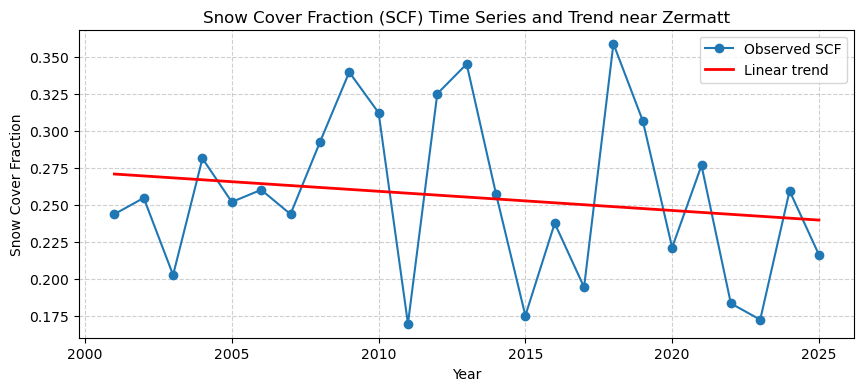

In [3]:
# Write your code here

zermatt_x = 4146515
zermatt_y = 2547946

zermatt_scf_cube = scf_cube.sel(x=zermatt_x, y=zermatt_y, method="nearest")

scf_cube_fit = zermatt_scf_cube.polyfit(dim="time", deg=1)
scf_cube_slope = scf_cube_fit.polyfit_coefficients.sel(degree=1)

scf_cube_trend_line = xr.polyval(zermatt_scf_cube.time, scf_cube_fit.polyfit_coefficients)

plt.figure(figsize=(10, 4))
zermatt_scf_cube.plot(marker="o", label="Observed SCF")
scf_cube_trend_line.plot(color="red", linewidth=2, label="Linear trend")

plt.title("Snow Cover Fraction (SCF) Time Series and Trend near Zermatt")
plt.ylabel("Snow Cover Fraction")
plt.xlabel("Year")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

---

## Part 3 – Pixel-Wise Trend

Looking at a single location is useful, but the Ski Resorts Council needs a regional overview. We want to collapse our 3D data cube into a 2D map showing the *rate of change* (the slope of the linear trend line) for every single pixel in the Alps.

### Tasks
1. **Calculate the Trend:** Use `xarray`'s built-in `.polyfit(dim="time", deg=1)` function on your `scf_cube` to perform linear regression down the time axis.
2. **Extract and Scale the Slope:** Extract the `polyfit_coefficients` for `degree=1`. Multiply by 10 to convert the annual rate of change into a **decadal trend** (change per 10 years).
3. **Apply Masking:** Use the `lakes_raw` data to mask out water bodies, which are prone to outliers (due to snow/water confusion).
4. **Visualize the Trend:** Plot the result using a diverging colormap (like `RdBu`) and overlay the Alpine perimeter for context.

/Users/jonasbezencon/miniconda3/envs/sds-env/lib/python3.12/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


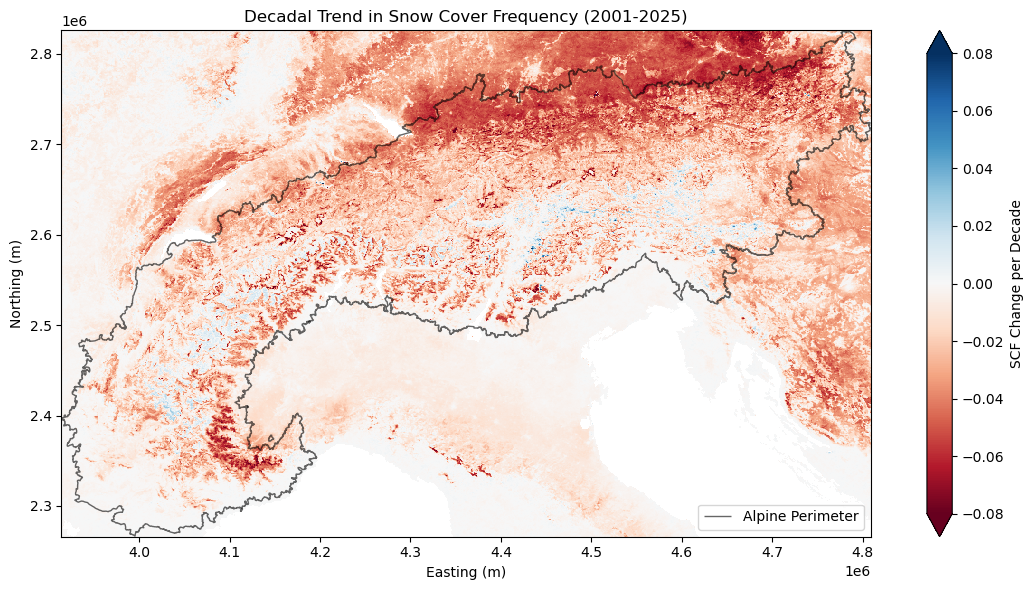

In [4]:
# Write your code here

global_trend = scf_cube.polyfit(dim="time", deg=1)
global_trend_slope = global_trend.polyfit_coefficients.sel(degree=1) * 10

lake_mask = clipped_lake.squeeze()
trend_map_masked = global_trend_slope.where(lake_mask == 0)

fig, ax = plt.subplots(figsize=(12, 6))

# Use RdBu_r so red indicates a negative trend (snow loss)
trend_map_masked.plot(
    ax=ax, 
    cmap='RdBu', 
    vmin=-0.08,
    vmax=0.08,
    cbar_kwargs={'label': 'SCF Change per Decade'}
)

# Overlay Perimeter
perimeter.boundary.plot(
    ax=ax, 
    color="black", 
    linewidth=1, 
    alpha=0.6,
    label="Alpine Perimeter"
)

ax.set_title("Decadal Trend in Snow Cover Frequency (2001-2025)")
plt.legend(loc='lower right')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.tight_layout()
plt.show()

---

## Part 4 – Environmental Analysis

We have a map of snow decline and a DEM showing elevation. Are lower-elevation ski resorts suffering more severe snow loss than higher-elevation ones? Let's sample our raster data at the exact locations of the chairlifts to find out.

To conclude our investigation, we will intersect the regional trend data with specific infrastructure (chairlifts) to see if elevation plays a role in the observed snow cover decline.

### Tasks
1. **Environment Setup:** Import `hvplot` for interactive web-based visualizations.
2. **Point Sampling:** Extract the X and Y coordinates of the chairlift centroids and sample both the **Decadal Trend Map** and the **DEM** at each lift's location using `.sel(method='nearest')`.
3. **Statistical Regression:** Use `np.polyfit` to calculate a linear regression between elevation and the rate of snow cover change.
4. **Interactive Visualization:** Create an [interactive scatter plot](https://hvplot.holoviz.org/en/docs/latest/ref/api/manual/hvplot.hvPlot.scatter.html) using `hvplot`, overlaying the regression [line](https://hvplot.holoviz.org/en/docs/latest/ref/api/manual/hvplot.hvPlot.line.html#hvplot.hvPlot.line) to visualize the relationship between topography and snow trends.

In [10]:
# Write your code here

import pandas as pd
import hvplot.pandas

x_coords = chairlifts_pts.geometry.x.values
y_coords = chairlifts_pts.geometry.y.values

chairlift_map_trend = []
chairlift_map_dem = []

for x, y in zip(x_coords, y_coords):
    chairlift_map_trend.append(trend_map_masked.sel(x=x, y=y, method="nearest").values.item())
    chairlift_map_dem.append(clipped_dem.sel(x=x, y=y, method="nearest").values.item())

chairlifts_pts["chairlift_map_trend"] = chairlift_map_trend
chairlifts_pts["chairlift_map_dem"] = chairlift_map_dem

chairlifts_pts = chairlifts_pts.dropna(subset=['chairlift_map_trend', 'chairlift_map_dem'])

x_reg = chairlifts_pts['chairlift_map_trend']
y_reg = chairlifts_pts['chairlift_map_dem']

reg = np.polyfit(
    x=x_reg,
    y=y_reg,
    deg=1
)

slope = np.poly1d(reg)

scatter_plot = chairlifts_pts.hvplot.scatter(
    x='chairlift_map_trend',
    y='chairlift_map_dem',
    hover_cols=['name', 'chairlift_map_trend', 'chairlift_map_dem'],
    alpha=0.6,
    size=40,
    color='blue',
    title='Chairlift Analysis: Linear SCF Trend vs. Elevation',
    xlabel='SCF Change per Decade',
    ylabel='Elevation (m)',
    width=800,
    height=500,
    grid=True
)

# Create the regression line for plotting
x_vals = np.linspace(x_reg.min(), y_reg.max(), 100)
y_vals = slope(x_vals)
line_df = pd.DataFrame({'x': x_vals, 'y': y_vals})
reg_line = line_df.hvplot.line(x='x', y='y', color='red', line_width=2, label=f'Linear Fit: y={reg[0]:.2f}x + {reg[1]:.2f}')

# Combine and display
scatter_plot * reg_line

:Overlay
   .Scatter.I                                                                  :Scatter   [chairlift_map_trend]   (chairlift_map_dem,name)
   .Curve.Linear_Fit_colon_y_equals_14786_full_stop_50x_plus_2189_full_stop_40 :Curve   [x]   (y)

---

## Reflection

Take a step back and review what you have built. You navigated a multi-dimensional array, quantified historical trends, and merged raster math with vector point locations to generate actionable intelligence. 

Please answer the following questions briefly:

1. **Memory Efficiency:** In Part 1, we used `.rio.clip_box()` instead of a detailed polygon mask before doing our analysis. Why is clipping to a bounding box generally a safer first step when dealing with massive multi-decadal data cubes?
2. **The Power of `.polyfit()`:** In Part 3, you calculated the linear trend for potentially millions of pixels with a single command. If you had to write a standard Python `for` loop to calculate the slope for every single pixel in the X and Y dimensions over 25 years, what would that code look like structurally, and why would it be problematic?
3. **Interpreting the Scatterplot:** Based on your output in Part 4, what advice would you give to the Swiss Ski Resorts Council regarding future infrastructure investments (like planning new chairlifts)?

In [ ]:
# Write your reflections here